In [1]:
#import libraries
import pandas as pd
import numpy as np
from glob import glob

In [2]:
#load review data
review_files = sorted(
    glob("../../data/raw/yelp/yelp_review_sample_part_*.parquet")
)

print("Review files:", len(review_files))

reviews = pd.concat(
    [pd.read_parquet(file) for file in review_files],
    ignore_index=True
)

print("Review dataset shape:", reviews.shape)
print("\nColumns:")
print(reviews.columns.tolist())

Review files: 10
Review dataset shape: (990521, 9)

Columns:
['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


In [3]:
#validation
assert len(review_files) == 10
assert reviews["review_id"].is_unique
assert reviews["business_id"].notna().all()
assert reviews["date"].notna().all()
assert reviews["text"].notna().all()

print("Review dataset validation passed.")

Review dataset validation passed.


In [4]:
#load merchant status
merchant_status = pd.read_csv(
    "../../data/samples/yelp_merchant_engagement.csv",
    usecols=["business_id", "merchant_status"]
)

print("Merchant dataset shape:", merchant_status.shape)
print("\nMerchant status distribution:")
print(merchant_status["merchant_status"].value_counts())

Merchant dataset shape: (8812, 2)

Merchant status distribution:
merchant_status
Stable       4266
Declining    2361
Growing      2185
Name: count, dtype: int64


In [5]:
#validate
assert merchant_status["business_id"].is_unique
assert merchant_status["merchant_status"].notna().all()

print("Merchant status validation passed.")

Merchant status validation passed.


In [6]:
#merge status onto reviews
reviews = reviews.merge(
    merchant_status,
    on="business_id",
    how="inner",
    validate="many_to_one"
)

print("Merged review shape:", reviews.shape)
print("Unique businesses:", reviews["business_id"].nunique())
print("Missing merchant status:", reviews["merchant_status"].isna().sum())

Merged review shape: (990521, 10)
Unique businesses: 8812
Missing merchant status: 0


In [7]:
#validate
assert reviews.shape[0] == 990521
assert reviews["review_id"].is_unique
assert reviews["merchant_status"].notna().all()

print("Review-status merge validation passed.")

Review-status merge validation passed.


In [8]:
#establish the analysis window
analysis_end = reviews["date"].max()

recent_start = analysis_end - pd.DateOffset(months=6)
earlier_start = analysis_end - pd.DateOffset(months=12)

print("Analysis end:", analysis_end)
print("Recent window:", recent_start, "to", analysis_end)
print("Earlier window:", earlier_start, "to", recent_start)

Analysis end: 2022-01-19 19:46:34
Recent window: 2021-07-19 19:46:34 to 2022-01-19 19:46:34
Earlier window: 2021-01-19 19:46:34 to 2021-07-19 19:46:34


In [9]:
recent_reviews = reviews[
    (reviews["date"] >= recent_start) &
    (reviews["date"] <= analysis_end)
].copy()

earlier_reviews = reviews[
    (reviews["date"] >= earlier_start) &
    (reviews["date"] < recent_start)
].copy()

print("\nReviews in analysis windows:")
print("Recent:", len(recent_reviews))
print("Earlier:", len(earlier_reviews))


Reviews in analysis windows:
Recent: 34400
Earlier: 34920


In [10]:
#feasibility analysis
status_window_counts = (
    pd.concat([
        recent_reviews.assign(period="recent"),
        earlier_reviews.assign(period="earlier")
    ])
    .groupby(["business_id", "merchant_status", "period"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

status_window_counts.head()

period,business_id,merchant_status,earlier,recent
0,-0TffRSXXIlBYVbb5AwfTg,Declining,57,47
1,-1B9pP_CrRBJYPICE5WbRA,Declining,14,13
2,-1oygVebK81K8JEPI6H6Lw,Growing,2,6
3,-2dvQxx3cYXd5XmFdDDsDA,Declining,3,4
4,-2wh7NTLkWEgsrLJvilnFQ,Growing,22,27


In [11]:
#ensure both column exist
for period in ["earlier", "recent"]:
    if period not in status_window_counts.columns:
        status_window_counts[period] = 0

In [12]:
#merchant eligibility by status
status_window_counts["has_earlier"] = (
    status_window_counts["earlier"] > 0
)

status_window_counts["has_recent"] = (
    status_window_counts["recent"] > 0
)

status_window_counts["has_both"] = (
    status_window_counts["has_earlier"] &
    status_window_counts["has_recent"]
)

In [13]:
#summary
eligibility_summary = (
    status_window_counts
    .groupby("merchant_status")
    .agg(
        merchants=("business_id", "nunique"),
        with_earlier=("has_earlier", "sum"),
        with_recent=("has_recent", "sum"),
        with_both=("has_both", "sum")
    )
)

eligibility_summary["earlier_pct"] = (
    eligibility_summary["with_earlier"] /
    eligibility_summary["merchants"] * 100
)

eligibility_summary["recent_pct"] = (
    eligibility_summary["with_recent"] /
    eligibility_summary["merchants"] * 100
)

eligibility_summary["both_pct"] = (
    eligibility_summary["with_both"] /
    eligibility_summary["merchants"] * 100
)

eligibility_summary

,merchants,with_earlier,with_recent,with_both,earlier_pct,recent_pct,both_pct
merchant_status,,,,,,,
Declining,2349,2346,1757,1754,99.872286,74.797786,74.670072
Growing,2164,1533,2162,1531,70.841035,99.907579,70.748614
Stable,367,353,331,317,96.185286,90.190736,86.376022


### Merchant Eligibility Across Analysis Windows

Merchant eligibility was assessed using the same **six-month earlier and recent review windows** used for the engagement analysis.

A merchant was considered eligible for sentiment comparison if it had **at least one review in both periods**, ensuring that earlier-versus-recent sentiment could be compared at the merchant level.

Eligible merchants by health status:

* **Declining:** 1,754
* **Stable:** 317
* **Growing:** 1,531

Sufficient merchants were available across all three categories to support **stratified sampling for sentiment analysis**.


In [14]:
eligibility_chart = (
    eligibility_summary
    .reset_index()[["merchant_status", "with_both"]]
)

eligibility_chart

,merchant_status,with_both
0,Declining,1754
1,Growing,1531
2,Stable,317


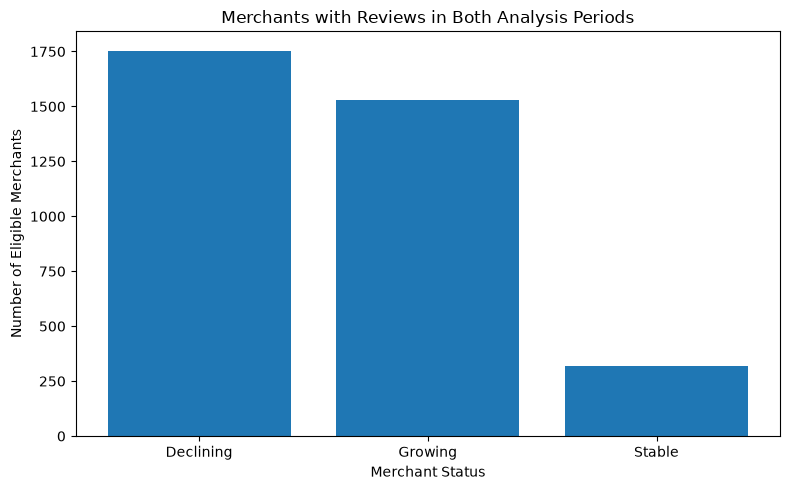

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    eligibility_chart["merchant_status"],
    eligibility_chart["with_both"]
)

plt.title("Merchants with Reviews in Both Analysis Periods")
plt.xlabel("Merchant Status")
plt.ylabel("Number of Eligible Merchants")

plt.tight_layout()
plt.show()

### Sampling Decision

A **stratified sample of 300 merchants** will be selected, with equal representation across health categories:

* **100 Declining**
* **100 Stable**
* **100 Growing**

Equal allocation is used to enable a direct comparison of sentiment across merchant health categories rather than mirror the overall population distribution.Only merchants with at least one eligible review in **both analysis periods** will be considered for sampling.

This is a **comparative, rather than population-proportional, sample**.


In [16]:
#identify merchants eligible in both periods
eligible_merchants = status_window_counts[
    status_window_counts["has_both"]
].copy()

print("Eligible merchants with reviews in BOTH periods:")
print(
    eligible_merchants["merchant_status"]
    .value_counts()
    .sort_index()
)

print("\nTotal eligible merchants:", len(eligible_merchants))

Eligible merchants with reviews in BOTH periods:
merchant_status
Declining    1754
Growing      1531
Stable        317
Name: count, dtype: int64

Total eligible merchants: 3602


In [17]:
#validate eligibility count
expected_eligible = {
    "Declining": 1754,
    "Growing": 1531,
    "Stable": 317
}

actual_eligible = (
    eligible_merchants["merchant_status"]
    .value_counts()
    .to_dict()
)

assert actual_eligible == expected_eligible

print("Eligibility counts validated.")

Eligibility counts validated.


In [18]:
#set sampling parameters
RANDOM_SEED = 42
MERCHANTS_PER_STATUS = 100

In [19]:
#stratifies merchant sampling
sampled_merchants = (
    eligible_merchants
    .groupby("merchant_status", group_keys=False)
    .sample(
        n=MERCHANTS_PER_STATUS,
        random_state=RANDOM_SEED
    )
    .copy()
)

print("Selected merchants:", len(sampled_merchants))
print("\nSelected merchants by status:")
print(
    sampled_merchants["merchant_status"]
    .value_counts()
    .sort_index()
)

Selected merchants: 300

Selected merchants by status:
merchant_status
Declining    100
Growing      100
Stable       100
Name: count, dtype: int64


In [20]:
#validate the 300 merchants
assert len(sampled_merchants) == 300
assert sampled_merchants["business_id"].is_unique

status_counts = sampled_merchants["merchant_status"].value_counts()

assert status_counts["Declining"] == 100
assert status_counts["Stable"] == 100
assert status_counts["Growing"] == 100

print("Stratified merchant sampling validation passed.")

Stratified merchant sampling validation passed.


In [21]:
#filter reviews of the selected 300 merchants
selected_business_ids = sampled_merchants["business_id"].tolist()

sampled_review_pool = reviews[
    reviews["business_id"].isin(selected_business_ids)
].copy()

print("Reviews for selected merchants:", len(sampled_review_pool))
print("Merchants represented:", sampled_review_pool["business_id"].nunique())

Reviews for selected merchants: 65377
Merchants represented: 300


In [22]:
assert sampled_review_pool["business_id"].nunique() == 300

print("Selected merchant review-pool validation passed.")

Selected merchant review-pool validation passed.


In [23]:
#split into earlier and recent windows
selected_recent = sampled_review_pool[
    (sampled_review_pool["date"] >= recent_start) &
    (sampled_review_pool["date"] <= analysis_end)
].copy()

selected_earlier = sampled_review_pool[
    (sampled_review_pool["date"] >= earlier_start) &
    (sampled_review_pool["date"] < recent_start)
].copy()

print("Recent reviews:", len(selected_recent))
print("Earlier reviews:", len(selected_earlier))

Recent reviews: 2590
Earlier reviews: 2656


In [24]:
#review count per merchant
recent_counts = (
    selected_recent
    .groupby("business_id")
    .size()
    .rename("recent_review_count")
)

earlier_counts = (
    selected_earlier
    .groupby("business_id")
    .size()
    .rename("earlier_review_count")
)

merchant_review_availability = (
    sampled_merchants[["business_id", "merchant_status"]]
    .set_index("business_id")
    .join(earlier_counts)
    .join(recent_counts)
    .fillna(0)
    .reset_index()
)

merchant_review_availability[
    ["earlier_review_count", "recent_review_count"]
] = merchant_review_availability[
    ["earlier_review_count", "recent_review_count"]
].astype(int)

merchant_review_availability.head()

,business_id,merchant_status,earlier_review_count,recent_review_count
0,AlH5V97JSAu7AL_xdibMIg,Declining,60,56
1,DhZVpgeBKxoLd91MiwTxpg,Declining,16,10
2,DZglT5FP5VNDQJU3PuRIHw,Declining,21,17
3,FImeJg7pVG9K7wjuexmV4Q,Declining,1,1
4,qCpdeQYPf9i1EZhTnQgjtg,Declining,7,6


In [25]:
#overall availability summary
print("Earlier review counts:")
print(
    merchant_review_availability["earlier_review_count"].describe()
)

print("\nRecent review counts:")
print(
    merchant_review_availability["recent_review_count"].describe()
)

Earlier review counts:
count    300.000000
mean       8.853333
std       12.398828
min        1.000000
25%        2.000000
50%        5.000000
75%       11.000000
max      123.000000
Name: earlier_review_count, dtype: float64

Recent review counts:
count    300.000000
mean       8.633333
std       12.745472
min        1.000000
25%        2.000000
50%        5.000000
75%       10.000000
max      130.000000
Name: recent_review_count, dtype: float64


In [26]:
#availability by merchant status
availability_by_status = (
    merchant_review_availability
    .groupby("merchant_status")[
        ["earlier_review_count", "recent_review_count"]
    ]
    .agg(["count", "mean", "median", "min", "max"])
)

availability_by_status

earlier_review_count                         \
                               count   mean median min  max   
merchant_status                                               
Declining                        100  10.42    7.0   1   60   
Growing                          100  10.90    5.0   1  123   
Stable                           100   5.24    3.0   1   31   

                recent_review_count                         
                              count   mean median min  max  
merchant_status                                             
Declining                       100   7.83    5.0   1   56  
Growing                         100  13.12    8.0   1  130  
Stable                          100   4.95    3.0   1   27

In [27]:
#check how many can provide 5 reviews per period
merchant_review_availability["has_5_earlier"] = (
    merchant_review_availability["earlier_review_count"] >= 5
)

merchant_review_availability["has_5_recent"] = (
    merchant_review_availability["recent_review_count"] >= 5
)

merchant_review_availability["has_5_both"] = (
    merchant_review_availability["has_5_earlier"] &
    merchant_review_availability["has_5_recent"]
)

print(
    "Merchants with >=5 earlier reviews:",
    merchant_review_availability["has_5_earlier"].sum()
)

print(
    "Merchants with >=5 recent reviews:",
    merchant_review_availability["has_5_recent"].sum()
)

print(
    "Merchants with >=5 reviews in BOTH periods:",
    merchant_review_availability["has_5_both"].sum()
)

Merchants with >=5 earlier reviews: 155
Merchants with >=5 recent reviews: 157
Merchants with >=5 reviews in BOTH periods: 125


#### Review Sampling Decision

Each selected merchant contributes **up to 5 reviews from each six-month period**.

A cap of 5 reviews keeps GenAI processing manageable while providing enough recent observations to represent each merchant. Merchants with fewer than 5 eligible reviews contribute all available reviews.

Within each period, the **5 most recent eligible reviews** are selected rather than randomly sampled. This provides a consistent and reproducible representation of sentiment during the relevant time window.

With 300 selected merchants, the maximum sample is:

* **1,500 earlier-period reviews**
* **1,500 recent-period reviews**
* **3,000 reviews in total**

This approach balances **time relevance, consistency, and processing efficiency**.


In [28]:
#create the capped reviews sample
selected_recent_sample = (
    selected_recent
    .sort_values(["business_id", "date"], ascending=[True, False])
    .groupby("business_id")
    .head(5)
    .copy()
)

selected_earlier_sample = (
    selected_earlier
    .sort_values(["business_id", "date"], ascending=[True, False])
    .groupby("business_id")
    .head(5)
    .copy()
)

print("Sampled recent reviews:", len(selected_recent_sample))
print("Sampled earlier reviews:", len(selected_earlier_sample))

Sampled recent reviews: 1100
Sampled earlier reviews: 1093


In [29]:
#add period lables
selected_recent_sample["period"] = "recent"
selected_earlier_sample["period"] = "earlier"

In [30]:
#combine the samples
sentiment_sample = pd.concat(
    [
        selected_earlier_sample,
        selected_recent_sample
    ],
    ignore_index=True
)

print("Final sentiment review sample:", len(sentiment_sample))

Final sentiment review sample: 2193


In [31]:
#attach merchant status
sentiment_sample = sentiment_sample.merge(
    sampled_merchants[["business_id", "merchant_status"]],
    on="business_id",
    how="left",
    validate="many_to_one"
)

print(sentiment_sample.shape)

(2193, 12)


In [32]:
#validate the final sample
print(sentiment_sample.columns.tolist())

['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'merchant_status_x', 'period', 'merchant_status_y']


In [33]:
# Check that both status columns agree

assert (
    sentiment_sample["merchant_status_x"]
    == sentiment_sample["merchant_status_y"]
).all()

print("Both merchant_status columns agree.")

Both merchant_status columns agree.


In [34]:
# Keep a single merchant_status column

sentiment_sample["merchant_status"] = sentiment_sample["merchant_status_x"]

sentiment_sample = sentiment_sample.drop(
    columns=["merchant_status_x", "merchant_status_y"]
)

print(sentiment_sample.columns.tolist())

['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'period', 'merchant_status']


In [35]:
# Validate the final sample

assert sentiment_sample["business_id"].nunique() <= 300
assert sentiment_sample["merchant_status"].notna().all()
assert sentiment_sample["period"].isin(["earlier", "recent"]).all()

# No merchant should have more than 5 reviews in either period
counts = (
    sentiment_sample
    .groupby(["business_id", "period"])
    .size()
)

assert counts.max() <= 5

print("Final sentiment sample validation passed.")

Final sentiment sample validation passed.


In [36]:
#review counts by period
print("Reviews by period:")
print(sentiment_sample["period"].value_counts())

print("\nReviews by merchant status:")
print(sentiment_sample["merchant_status"].value_counts())

print("\nReviews by status and period:")
print(
    sentiment_sample
    .groupby(["merchant_status", "period"])
    .size()
    .unstack(fill_value=0)
)

Reviews by period:
period
recent     1100
earlier    1093
Name: count, dtype: int64

Reviews by merchant status:
merchant_status
Declining    793
Growing      789
Stable       611
Name: count, dtype: int64

Reviews by status and period:
period           earlier  recent
merchant_status                 
Declining            408     385
Growing              376     413
Stable               309     302


In [37]:
#merchant representation
represented_merchants = sentiment_sample["business_id"].nunique()

print("Selected merchants:", len(sampled_merchants))
print("Merchants represented in sentiment sample:", represented_merchants)

print("\nMerchants represented by status:")
print(
    sentiment_sample
    .drop_duplicates("business_id")
    ["merchant_status"]
    .value_counts()
    .sort_index()
)

Selected merchants: 300
Merchants represented in sentiment sample: 300

Merchants represented by status:
merchant_status
Declining    100
Growing      100
Stable       100
Name: count, dtype: int64


In [38]:
assert represented_merchants == 300

In [39]:
#verify every merchant has both periods
period_coverage = (
    sentiment_sample
    .groupby(["business_id", "period"])
    .size()
    .unstack(fill_value=0)
)

assert (period_coverage["earlier"] > 0).all()
assert (period_coverage["recent"] > 0).all()

print("All 300 merchants have reviews in both periods.")

All 300 merchants have reviews in both periods.


In [40]:
print("Final review sample size:", len(sentiment_sample))

print("\nMaximum reviews per merchant-period:")
print(
    sentiment_sample
    .groupby(["business_id", "period"])
    .size()
    .max()
)

assert len(sentiment_sample) <= 3000
assert (
    sentiment_sample
    .groupby(["business_id", "period"])
    .size()
    .max()
    <= 5
)

print("Review cap validation passed.")

Final review sample size: 2193

Maximum reviews per merchant-period:
5
Review cap validation passed.


In [41]:
#check for duplicate reviews
duplicate_reviews = sentiment_sample["review_id"].duplicated().sum()

print("Duplicate review IDs:", duplicate_reviews)

assert duplicate_reviews == 0

print("Review uniqueness validation passed.")

Duplicate review IDs: 0
Review uniqueness validation passed.


In [42]:
#final sample validation
assert sentiment_sample["business_id"].nunique() == 300
assert sentiment_sample["merchant_status"].notna().all()
assert sentiment_sample["period"].isin(["earlier", "recent"]).all()
assert sentiment_sample["review_id"].is_unique

counts = (
    sentiment_sample
    .groupby(["business_id", "period"])
    .size()
)

assert counts.min() >= 1
assert counts.max() <= 5
assert len(sentiment_sample) <= 3000

print("Final sentiment sampling validation passed.")

Final sentiment sampling validation passed.


In [43]:
#save the final sentiment sample
sentiment_sample_path = "../../data/samples/yelp_sentiment_sample.csv"

sentiment_sample.to_csv(
    sentiment_sample_path,
    index=False
)

print(f"Saved: {sentiment_sample_path}")
print(f"Shape: {sentiment_sample.shape}")

Saved: ../../data/samples/yelp_sentiment_sample.csv
Shape: (2193, 11)


In [44]:
#relode and validate the saved file
sentiment_check = pd.read_csv(sentiment_sample_path)

assert sentiment_check.shape == sentiment_sample.shape
assert sentiment_check["review_id"].is_unique
assert sentiment_check["business_id"].nunique() == 300
assert sentiment_check["merchant_status"].notna().all()
assert sentiment_check["period"].isin(["earlier", "recent"]).all()

print("Saved sentiment sample validation passed.")
print("Shape:", sentiment_check.shape)
print("Unique merchants:", sentiment_check["business_id"].nunique())
print("Unique reviews:", sentiment_check["review_id"].nunique())

Saved sentiment sample validation passed.
Shape: (2193, 11)
Unique merchants: 300
Unique reviews: 2193


#### Review Sampling Strategy

A stratified sample of **300 merchants** was used for comparative sentiment analysis, with equal representation across Declining, Stable, and Growing merchants.

For each selected merchant, up to **5 most recent eligible reviews per period** were retained.

**Sample Validation**

The final sample contains **2,193 unique reviews**:
* **1,093** earlier-period reviews
* **1,100** recent-period reviews
* **300 merchants** represented in both periods
* **Maximum of 5 reviews per merchant per period**
* **Duplicate review IDs:** 0

The resulting sample is designed for **comparative merchant-level sentiment analysis**, rather than population-level sentiment estimation.
